# Training

This notebook trains Random Forest and Support Vector Machine (SVM) models for music genre classification. Hyperparameter tuning is used to select the settings for both models.

The prepared training files contain 804 tracks and 75 audio features. Testing and model evaluation are handled separately.

## 1. Import libraries

The required libraries are imported for data loading, model training, feature scaling, and hyperparameter tuning.

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

RANDOM_STATE = 42

## 2. Load the prepared training data

**X_train.csv** contains the 75 audio features, and **y_train.csv** contains the genre label for each of the 804 training tracks.

In [6]:
X_train = pd.read_csv('X_train.csv')
X_train = X_train.drop(columns='filename')
y_train = pd.read_csv('y_train.csv')['genre']
print('Training data shape:', X_train.shape)
print('Training labels:', y_train.shape)
print('Number of features:', X_train.shape[1])
print('Missing feature values:', X_train.isna().sum().sum())
print('Missing labels:', y_train.isna().sum())
display(y_train.value_counts().sort_index().to_frame('number_of_tracks'))

Training data shape: (804, 75)
Training labels: (804,)
Number of features: 75
Missing feature values: 0
Missing labels: 0


,number_of_tracks
genre,
blues,80
classical,80
country,80
disco,80
hiphop,81
jazz,79
metal,83
pop,81
reggae,80


## 3. Cross-validation setup

Five-fold stratified cross-validation is used during hyperparameter tuning. The training data is divided into five folds while keeping similar genre proportions in each fold.

Macro F1 is used as the selection score because it gives equal importance to all ten genres.

In [7]:
cv_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 4. Random Forest hyperparameter tuning and training

The following Random Forest settings are tested:

- **n_estimators**: number of trees in the forest
- **max_depth**: maximum depth of each tree
- **max_features**: number of features considered at each split
- **min_samples_split**: minimum number of samples needed to split a node
- **min_samples_leaf**: minimum number of samples kept in a leaf
- **criterion**: method used to measure the quality of a split
- **class_weight**: whether class frequencies are balanced automatically

The parameter space contains many possible combinations. Randomised search checks 30 combinations using five-fold cross-validation. The selected parameters are then used to train the final Random Forest on all 804 training tracks.

In [8]:
rf_classifier = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_search_space = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'max_depth': [None, 10, 20, 30, 40],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}
rf_search = RandomizedSearchCV(rf_classifier, rf_search_space, n_iter=30,
                               scoring='f1_macro', cv=cv_split, n_jobs=-1,
                               verbose=1, random_state=RANDOM_STATE)
rf_search.fit(X_train, y_train)
print('Best Random Forest parameters:')
print(rf_search.best_params_)
print('Best cross-validation macro F1:', round(rf_search.best_score_, 4))

best_rf = RandomForestClassifier(**rf_search.best_params_,
                                 random_state=RANDOM_STATE, n_jobs=-1)
best_rf.fit(X_train, y_train)
print('Final Random Forest training completed.')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Random Forest parameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'criterion': 'entropy', 'class_weight': None}
Best cross-validation macro F1: 0.6826
Final Random Forest training completed.


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_test = pd.read_csv('X_test.csv')
X_test = X_test.drop(columns='filename')
y_test = pd.read_csv('y_test.csv')['genre']
y_pred = best_rf.predict(X_test)

print(f"RF Accuracy: {accuracy_score(y_test, y_pred):.4}")
print(f"RF Precision: {precision_score(y_test, y_pred, average='macro'):.4}")
print(f"RF Recall: {recall_score(y_test, y_pred, average='macro'):.4}")
print(f"RF F1: {f1_score(y_test, y_pred, average='macro'):.4}")

RF Accuracy: 0.6667
RF Precision: 0.6681
RF Recall: 0.6691
RF F1: 0.6634


## 5. SVM hyperparameter tuning and training

SVM is sensitive to feature scale. The pipeline standardises the features within each cross-validation fold before training the classifier.
The following SVM settings are tested:

- **C**: controls the penalty for classification mistakes
- **gamma**: controls the influence of each training example for the RBF kernel
- **kernel**: determines the type of decision boundary
- **class_weight**: whether class frequencies are balanced automatically

Grid search checks all 72 combinations. The selected parameters are then used to train the final SVM pipeline on all 804 training tracks.

In [9]:
svm_pipeline = Pipeline([('scaler', StandardScaler()), ('svm', SVC())])
svm_search_space = [
    {'svm__kernel': ['linear'], 'svm__C': [0.1, 1, 5, 10, 50, 100],
     'svm__class_weight': [None, 'balanced']},
    {'svm__kernel': ['rbf'], 'svm__C': [0.1, 1, 5, 10, 50],
     'svm__gamma': ['scale', 0.001, 0.005, 0.01, 0.05, 0.1],
     'svm__class_weight': [None, 'balanced']}
]
svm_search = GridSearchCV(svm_pipeline, svm_search_space, scoring='f1_macro',
                          cv=cv_split, n_jobs=-1, verbose=1)
svm_search.fit(X_train, y_train)
print('Best SVM parameters:')
print(svm_search.best_params_)
print('Best cross-validation macro F1:', round(svm_search.best_score_, 4))

best_svm = Pipeline([('scaler', StandardScaler()), ('svm', SVC())])
best_svm.set_params(**svm_search.best_params_)
best_svm.fit(X_train, y_train)
print('Final SVM training completed.')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best SVM parameters:
{'svm__C': 5, 'svm__class_weight': None, 'svm__gamma': 0.005, 'svm__kernel': 'rbf'}
Best cross-validation macro F1: 0.742
Final SVM training completed.


In [18]:
y_pred = best_svm.predict(X_test)

print(f"SVM Accuracy: {accuracy_score(y_test, y_pred):.4}")
print(f"SVM Precision: {precision_score(y_test, y_pred, average='macro'):.4}")
print(f"SVM Recall: {recall_score(y_test, y_pred, average='macro'):.4}")
print(f"SVM F1: {f1_score(y_test, y_pred, average='macro'):.4}")

SVM Accuracy: 0.7487
SVM Precision: 0.7609
SVM Recall: 0.7505
SVM F1: 0.7448


## 6. Confusion matrices

A confusion matrix shows, for each true genre (rows), how often the model predicted each genre (columns). Values are **row-normalised**, so each row sums to 1.0 and the diagonal is the per-genre recall.

This makes it easier to see which genres are confused with each other (for example rock with country).

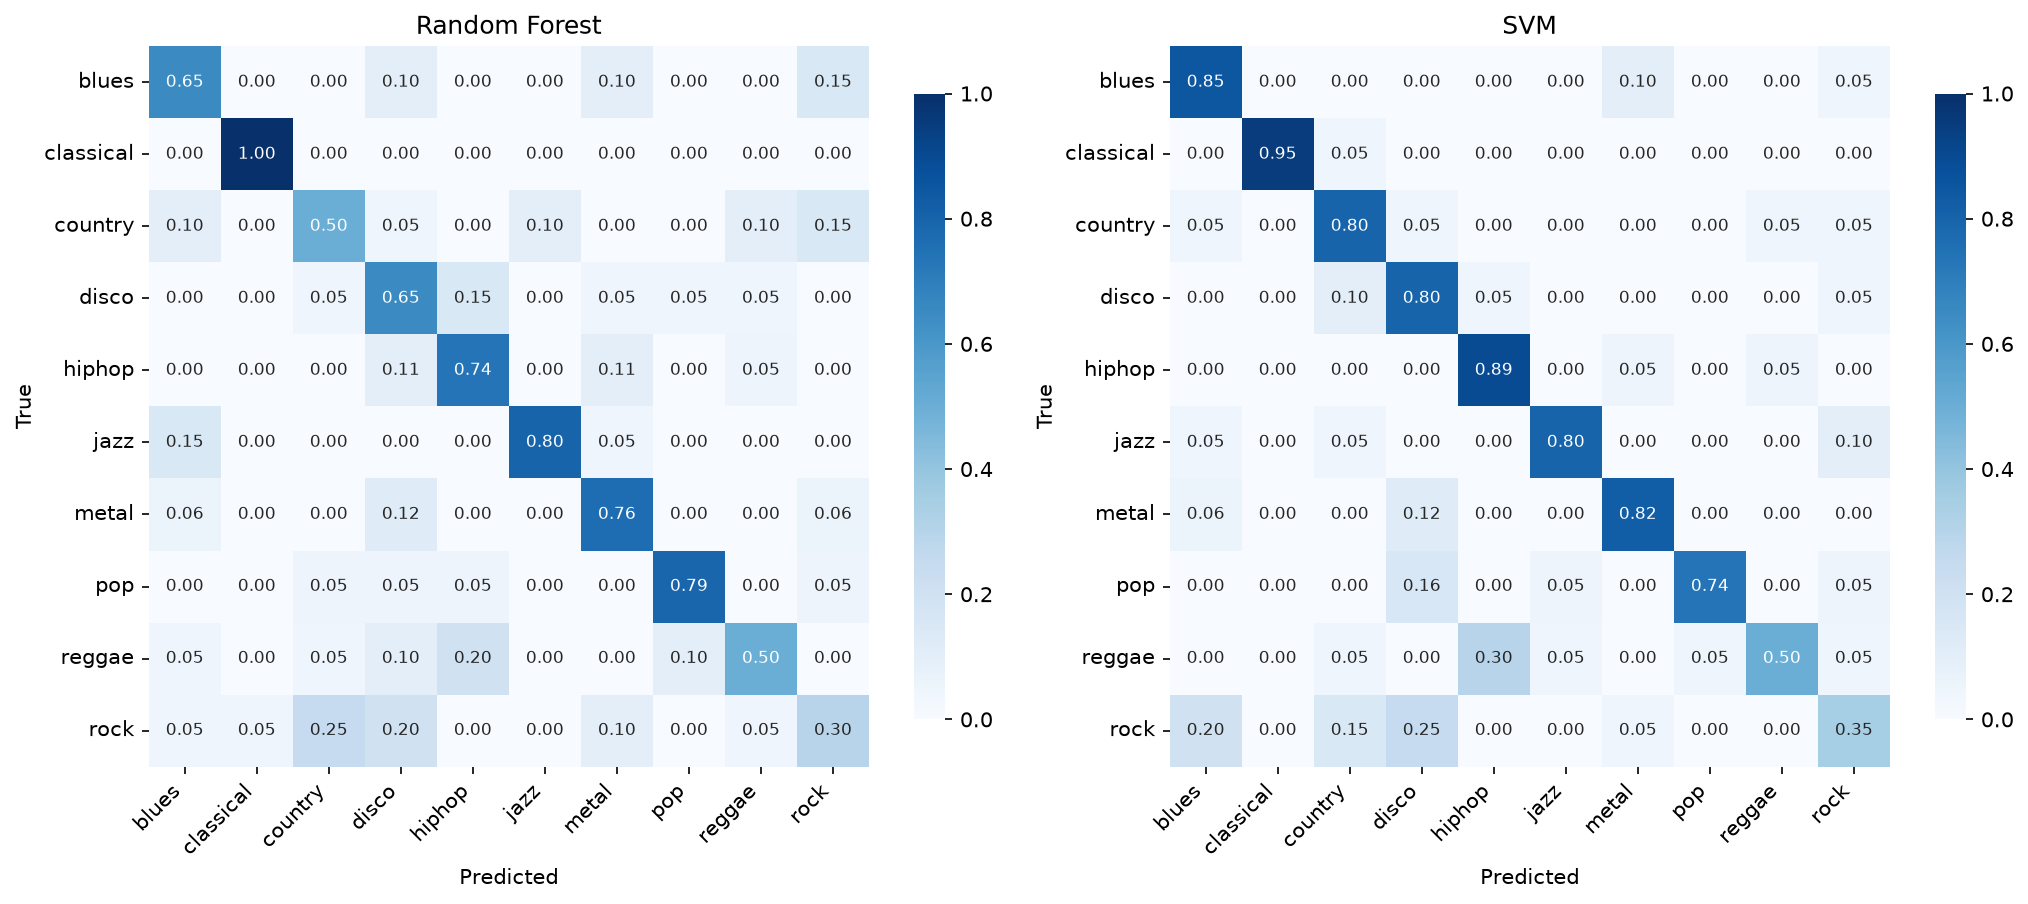

Saved figure to figures/05_rf_svm_confusion.png


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

genres = sorted(y_test.unique())
rf_pred = best_rf.predict(X_test)
svm_pred = best_svm.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title in [
    (axes[0], rf_pred, 'Random Forest'),
    (axes[1], svm_pred, 'SVM'),
]:
    cm = confusion_matrix(y_test, y_pred, labels=genres)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, ax=ax, cmap='Blues', vmin=0, vmax=1, square=True,
        xticklabels=genres, yticklabels=genres,
        annot=True, fmt='.2f', annot_kws={'size': 8},
        cbar_kws={'shrink': 0.8},
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('figures/05_rf_svm_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure to figures/05_rf_svm_confusion.png')
